In [1]:
import pandas as pd

df = pd.read_pickle("../scripts/data/checkpoint_after_cleaning.pkl")

df = df.rename(columns={'UTC': 'utc'})

df.head(10)

,latitude,longitude,utc,temperature_2m,precipitation,weather_code,wind_speed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,CO,NO2,OZONE,PM10,PM2.5,SO2
0,32.579361,-116.929486,2020-01-01 00:00:00+00:00,16.774500,0.0,0.0,5.804825,299.744780,15.48,65.068270,NaN,NaN,35.0,NaN,NaN,NaN
1,32.579361,-116.929486,2020-01-01 01:00:00+00:00,16.374498,0.0,0.0,4.104631,344.744800,7.92,51.225185,NaN,NaN,33.0,NaN,NaN,NaN
2,32.579361,-116.929486,2020-01-01 02:00:00+00:00,14.424500,0.0,0.0,5.692100,108.435040,7.20,55.308056,NaN,NaN,29.0,NaN,NaN,NaN
3,32.579361,-116.929486,2020-01-01 03:00:00+00:00,11.324500,0.0,0.0,9.904906,109.093590,13.32,64.299350,NaN,NaN,29.0,NaN,NaN,NaN
4,32.579361,-116.929486,2020-01-01 04:00:00+00:00,10.024500,0.0,0.0,10.182337,98.130020,14.04,64.229520,NaN,NaN,27.0,NaN,NaN,NaN
5,32.579361,-116.929486,2020-01-01 05:00:00+00:00,8.574500,0.0,0.0,9.779817,96.340096,14.40,70.065970,NaN,NaN,26.0,NaN,NaN,NaN
6,32.579361,-116.929486,2020-01-01 06:00:00+00:00,7.974500,0.0,0.0,7.695920,100.784256,13.32,71.446540,NaN,NaN,28.0,NaN,NaN,NaN
7,32.579361,-116.929486,2020-01-01 07:00:00+00:00,8.674500,0.0,0.0,11.792404,102.339070,14.40,63.920403,NaN,NaN,31.0,NaN,NaN,NaN
8,32.579361,-116.929486,2020-01-01 08:00:00+00:00,7.974500,0.0,0.0,12.964998,91.591110,18.00,67.987620,NaN,NaN,33.0,NaN,NaN,NaN
9,32.579361,-116.929486,2020-01-01 09:00:00+00:00,7.024500,0.0,0.0,13.755580,96.008920,19.80,72.541306,NaN,NaN,32.0,NaN,NaN,NaN


### Analyze missing data for each feature

In [2]:
pollutant = ['PM2.5', 'OZONE', 'NO2', 'SO2', 'CO', 'PM10']
weather_features = ['temperature_2m', 'precipitation', 'weather_code', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'relative_humidity_2m']

all_features = ['latitude', 'longitude', 'utc'] + weather_features + pollutant
existing_features = [f for f in all_features if f in df.columns]

missing_features = pd.DataFrame({
    'Feature': existing_features,
    'MissingCount': df[existing_features].isnull().sum(),
    'MissingPercent': (df[existing_features].isnull().sum() / len(df)) * 100,
})

missing_features_summary = missing_features[missing_features['MissingCount'] > 0].sort_values('MissingPercent', ascending=False)

print(missing_features_summary)

      Feature  MissingCount  MissingPercent
SO2       SO2       5238881       95.605549
CO         CO       4467060       81.520409
NO2       NO2       3704593       67.605973
PM2.5   PM2.5       2885428       52.656842
PM10     PM10       2751337       50.209784
OZONE   OZONE       1676569       30.596095


### Identify which pollutants are measured at each location

In [3]:
pollutants = ['PM2.5', 'OZONE', 'NO2', 'SO2', 'CO', 'PM10']

locations = df.groupby(['latitude', 'longitude'])

for (lat, lon), group in locations:
    measured = []
    for pollutant in pollutants:
        if group[pollutant].notna().any():
            measured.append(pollutant)

    print(f"({lat:.4f}, {lon:.4f}) → {measured}")

(32.5794, -116.9295) → ['PM2.5', 'OZONE', 'PM10']
(32.6292, -115.4469) → ['PM2.5']
(32.6312, -117.0591) → ['PM2.5', 'OZONE', 'PM10']
(32.6336, -115.5042) → ['PM2.5', 'OZONE', 'NO2', 'CO']
(32.6762, -115.4831) → ['PM2.5', 'OZONE', 'NO2', 'SO2', 'PM10']
(32.7102, -117.1427) → ['PM2.5', 'OZONE', 'PM10']
(32.7252, -116.3644) → ['OZONE']
(32.7355, -116.3454) → ['PM10']
(32.7504, -116.3315) → ['PM10']
(32.7896, -116.9442) → ['PM2.5', 'OZONE', 'PM10']
(32.7917, -115.5617) → ['PM2.5', 'OZONE', 'PM10']
(32.8423, -116.7683) → ['PM2.5', 'OZONE', 'PM10']
(32.8455, -117.1239) → ['PM2.5', 'OZONE', 'PM10']
(32.9783, -115.5383) → ['PM2.5', 'PM10']
(32.9854, -117.0822) → ['PM2.5', 'PM10']
(33.0325, -115.6225) → ['OZONE', 'PM10']
(33.2136, -115.5444) → ['OZONE', 'PM10']
(33.2170, -117.3962) → ['PM2.5', 'OZONE', 'PM10']
(33.3791, -116.0161) → ['PM2.5', 'PM10']
(33.4479, -117.0886) → ['PM2.5', 'OZONE']
(33.5611, -116.1536) → ['PM2.5', 'PM10']
(33.5720, -116.0638) → ['PM10']
(33.5831, -117.0722) → ['PM2.5'

###  Drop sites that do not measure label pm2.5.

In [4]:
pm25_by_location = df.groupby(['latitude', 'longitude'])['PM2.5'].apply(lambda x: x.notna().any())

valid_locations = pm25_by_location[pm25_by_location].index

print(f"\nSites with PM2.5 sensor: {len(valid_locations)}")
for lat, lon in valid_locations:
    print(f"({lat:.4f}, {lon:.4f})")


Sites with PM2.5 sensor: 71
(32.5794, -116.9295)
(32.6292, -115.4469)
(32.6312, -117.0591)
(32.6336, -115.5042)
(32.6762, -115.4831)
(32.7102, -117.1427)
(32.7896, -116.9442)
(32.7917, -115.5617)
(32.8423, -116.7683)
(32.8455, -117.1239)
(32.9783, -115.5383)
(32.9854, -117.0822)
(33.2170, -117.3962)
(33.3791, -116.0161)
(33.4479, -117.0886)
(33.5611, -116.1536)
(33.5831, -117.0722)
(33.6300, -117.6759)
(33.6765, -117.3310)
(33.7197, -116.1897)
(33.7254, -116.2068)
(33.7472, -115.8201)
(33.7937, -118.1710)
(33.8306, -117.9385)
(33.9014, -118.2050)
(33.9208, -116.8584)
(33.9446, -116.8303)
(33.9964, -117.4925)
(33.9994, -117.4158)
(34.0664, -118.2268)
(34.1001, -117.4920)
(34.1439, -117.8508)
(34.1820, -118.3630)
(34.1992, -118.5331)
(34.2102, -118.8705)
(34.2431, -117.2723)
(34.2524, -119.1432)
(34.2647, -116.8617)
(34.2763, -118.6837)
(34.3833, -118.5283)
(34.3942, -119.5147)
(34.4043, -118.8100)
(34.4278, -119.6909)
(34.4481, -119.2313)
(34.5110, -117.3256)
(34.7254, -118.1786)
(34.8

#### keep only rows from valid locations

In [5]:
df = df[df.set_index(['latitude', 'longitude']).index.isin(valid_locations)].reset_index(drop=True)

df.head(10)

,latitude,longitude,utc,temperature_2m,precipitation,weather_code,wind_speed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,CO,NO2,OZONE,PM10,PM2.5,SO2
0,32.579361,-116.929486,2020-01-01 00:00:00+00:00,16.774500,0.0,0.0,5.804825,299.744780,15.48,65.068270,NaN,NaN,35.0,NaN,NaN,NaN
1,32.579361,-116.929486,2020-01-01 01:00:00+00:00,16.374498,0.0,0.0,4.104631,344.744800,7.92,51.225185,NaN,NaN,33.0,NaN,NaN,NaN
2,32.579361,-116.929486,2020-01-01 02:00:00+00:00,14.424500,0.0,0.0,5.692100,108.435040,7.20,55.308056,NaN,NaN,29.0,NaN,NaN,NaN
3,32.579361,-116.929486,2020-01-01 03:00:00+00:00,11.324500,0.0,0.0,9.904906,109.093590,13.32,64.299350,NaN,NaN,29.0,NaN,NaN,NaN
4,32.579361,-116.929486,2020-01-01 04:00:00+00:00,10.024500,0.0,0.0,10.182337,98.130020,14.04,64.229520,NaN,NaN,27.0,NaN,NaN,NaN
5,32.579361,-116.929486,2020-01-01 05:00:00+00:00,8.574500,0.0,0.0,9.779817,96.340096,14.40,70.065970,NaN,NaN,26.0,NaN,NaN,NaN
6,32.579361,-116.929486,2020-01-01 06:00:00+00:00,7.974500,0.0,0.0,7.695920,100.784256,13.32,71.446540,NaN,NaN,28.0,NaN,NaN,NaN
7,32.579361,-116.929486,2020-01-01 07:00:00+00:00,8.674500,0.0,0.0,11.792404,102.339070,14.40,63.920403,NaN,NaN,31.0,NaN,NaN,NaN
8,32.579361,-116.929486,2020-01-01 08:00:00+00:00,7.974500,0.0,0.0,12.964998,91.591110,18.00,67.987620,NaN,NaN,33.0,NaN,NaN,NaN
9,32.579361,-116.929486,2020-01-01 09:00:00+00:00,7.024500,0.0,0.0,13.755580,96.008920,19.80,72.541306,NaN,NaN,32.0,NaN,NaN,NaN


## Check Missing Data Again

In [6]:

missing_features = pd.DataFrame({
    'Feature': existing_features,
    'MissingCount': df[existing_features].isnull().sum(),
    'MissingPercent': (df[existing_features].isnull().sum() / len(df)) * 100,
})

missing_features_summary = missing_features[missing_features['MissingCount'] > 0].sort_values('MissingPercent', ascending=False)

print(missing_features_summary)

      Feature  MissingCount  MissingPercent
SO2       SO2       2804419       92.092462
CO         CO       2479478       81.421939
NO2       NO2       2091216       68.672060
PM10     PM10       1565539       51.409701
OZONE   OZONE        607801       19.959175
PM2.5   PM2.5        450966       14.808974


## Drop columns with more than % missing data

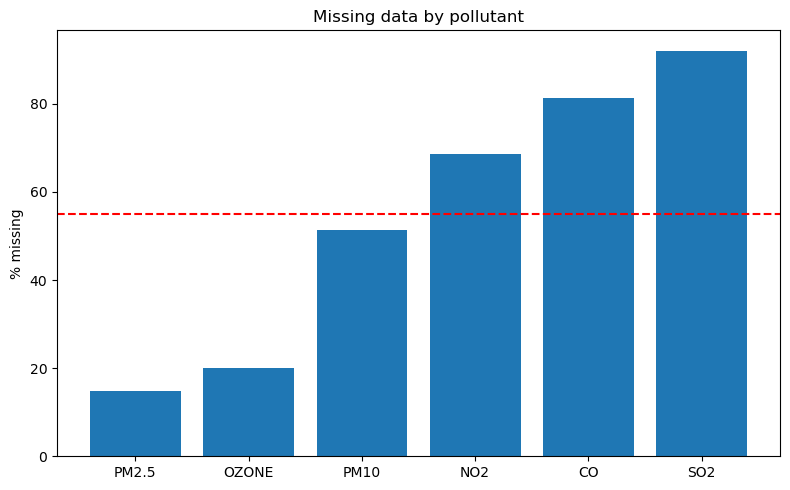

In [7]:
from matplotlib import pyplot as plt

percantage_threshold = 55

missing_percentage = df[pollutants].isna().mean().mul(100).sort_values()

interpulate_cols = pollutants

for pol, pct in missing_percentage.items():
    if pct > percantage_threshold:
        df = df.drop(columns=[pol])
        interpulate_cols.remove(pol)

plt.figure(figsize=(8,5))
plt.bar(missing_percentage.index, missing_percentage.values)
plt.axhline(percantage_threshold, color='red', linestyle='--')
plt.ylabel('% missing'); plt.title('Missing data by pollutant')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

### Flag and interpolate missing feature data

In [8]:

features = ['OZONE', 'PM10']

df.sort_values(['latitude', 'longitude', 'utc'])

for col in features:
    if col not in df.columns:
        continue

    df[col + '_missing_flag'] = df[col].isna().astype(int)

    df[col] = df.groupby(['latitude', 'longitude'])[col].transform(lambda x: x.interpolate(method='linear', limit=6).ffill().bfill())

    df[col] = df[col].fillna(df[col].median())


df.head(10)

,latitude,longitude,utc,temperature_2m,precipitation,weather_code,wind_speed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,OZONE,PM10,PM2.5,OZONE_missing_flag,PM10_missing_flag
0,32.579361,-116.929486,2020-01-01 00:00:00+00:00,16.774500,0.0,0.0,5.804825,299.744780,15.48,65.068270,35.0,17.0,NaN,0,1
1,32.579361,-116.929486,2020-01-01 01:00:00+00:00,16.374498,0.0,0.0,4.104631,344.744800,7.92,51.225185,33.0,17.0,NaN,0,1
2,32.579361,-116.929486,2020-01-01 02:00:00+00:00,14.424500,0.0,0.0,5.692100,108.435040,7.20,55.308056,29.0,17.0,NaN,0,1
3,32.579361,-116.929486,2020-01-01 03:00:00+00:00,11.324500,0.0,0.0,9.904906,109.093590,13.32,64.299350,29.0,17.0,NaN,0,1
4,32.579361,-116.929486,2020-01-01 04:00:00+00:00,10.024500,0.0,0.0,10.182337,98.130020,14.04,64.229520,27.0,17.0,NaN,0,1
5,32.579361,-116.929486,2020-01-01 05:00:00+00:00,8.574500,0.0,0.0,9.779817,96.340096,14.40,70.065970,26.0,17.0,NaN,0,1
6,32.579361,-116.929486,2020-01-01 06:00:00+00:00,7.974500,0.0,0.0,7.695920,100.784256,13.32,71.446540,28.0,17.0,NaN,0,1
7,32.579361,-116.929486,2020-01-01 07:00:00+00:00,8.674500,0.0,0.0,11.792404,102.339070,14.40,63.920403,31.0,17.0,NaN,0,1
8,32.579361,-116.929486,2020-01-01 08:00:00+00:00,7.974500,0.0,0.0,12.964998,91.591110,18.00,67.987620,33.0,17.0,NaN,0,1
9,32.579361,-116.929486,2020-01-01 09:00:00+00:00,7.024500,0.0,0.0,13.755580,96.008920,19.80,72.541306,32.0,17.0,NaN,0,1


### Check missing data after interpolation

In [9]:
missing_summary = pd.DataFrame({
    'Feature': ['PM2.5', 'OZONE', 'PM10'],
    'MissingPercent': [
        df['PM2.5'].isna().sum() / len(df) * 100 if 'PM2.5' in df.columns else 0,
        df['OZONE'].isna().sum() / len(df) * 100 if 'OZONE' in df.columns else 0,
        df['PM10'].isna().sum() / len(df) * 100 if 'PM10' in df.columns else 0
    ]
})

print("Missing data after interpolation:")
print(missing_summary.to_string(index=False))

Missing data after interpolation:
Feature  MissingPercent
  PM2.5       14.808974
  OZONE        0.000000
   PM10        0.000000


### Convert UTC to datetime

In [10]:
import numpy as np

# convert UTC to date/time
df['utc'] = pd.to_datetime(df['utc'], errors='coerce', utc=True)
# get hour of day
df['hr'] = df['utc'].dt.hour
# sine and cosine transformation for hour
df['sin_hr'] = np.sin(2 * np.pi * df['hr'] / 24)
df['cos_hr'] = np.cos(2 * np.pi * df['hr'] / 24)
# sine and cosine transformation for days
df['day'] = df['utc'].dt.dayofweek
df['sin_day'] = np.sin(2 * np.pi * df['day'] / 7)
df['cos_day'] = np.cos(2 * np.pi * df['day'] / 7)

df.head(10)

,latitude,longitude,utc,temperature_2m,precipitation,weather_code,wind_speed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,...,PM10,PM2.5,OZONE_missing_flag,PM10_missing_flag,hr,sin_hr,cos_hr,day,sin_day,cos_day
0,32.579361,-116.929486,2020-01-01 00:00:00+00:00,16.774500,0.0,0.0,5.804825,299.744780,15.48,65.068270,...,17.0,NaN,0,1,0,0.000000,1.000000e+00,2,0.0,-0.222521
1,32.579361,-116.929486,2020-01-01 01:00:00+00:00,16.374498,0.0,0.0,4.104631,344.744800,7.92,51.225185,...,17.0,NaN,0,1,1,0.258819,9.659258e-01,2,0.0,-0.222521
2,32.579361,-116.929486,2020-01-01 02:00:00+00:00,14.424500,0.0,0.0,5.692100,108.435040,7.20,55.308056,...,17.0,NaN,0,1,2,0.500000,8.660254e-01,2,0.0,-0.222521
3,32.579361,-116.929486,2020-01-01 03:00:00+00:00,11.324500,0.0,0.0,9.904906,109.093590,13.32,64.299350,...,17.0,NaN,0,1,3,0.707107,7.071068e-01,2,0.0,-0.222521
4,32.579361,-116.929486,2020-01-01 04:00:00+00:00,10.024500,0.0,0.0,10.182337,98.130020,14.04,64.229520,...,17.0,NaN,0,1,4,0.866025,5.000000e-01,2,0.0,-0.222521
5,32.579361,-116.929486,2020-01-01 05:00:00+00:00,8.574500,0.0,0.0,9.779817,96.340096,14.40,70.065970,...,17.0,NaN,0,1,5,0.965926,2.588190e-01,2,0.0,-0.222521
6,32.579361,-116.929486,2020-01-01 06:00:00+00:00,7.974500,0.0,0.0,7.695920,100.784256,13.32,71.446540,...,17.0,NaN,0,1,6,1.000000,6.123234e-17,2,0.0,-0.222521
7,32.579361,-116.929486,2020-01-01 07:00:00+00:00,8.674500,0.0,0.0,11.792404,102.339070,14.40,63.920403,...,17.0,NaN,0,1,7,0.965926,-2.588190e-01,2,0.0,-0.222521
8,32.579361,-116.929486,2020-01-01 08:00:00+00:00,7.974500,0.0,0.0,12.964998,91.591110,18.00,67.987620,...,17.0,NaN,0,1,8,0.866025,-5.000000e-01,2,0.0,-0.222521
9,32.579361,-116.929486,2020-01-01 09:00:00+00:00,7.024500,0.0,0.0,13.755580,96.008920,19.80,72.541306,...,17.0,NaN,0,1,9,0.707107,-7.071068e-01,2,0.0,-0.222521


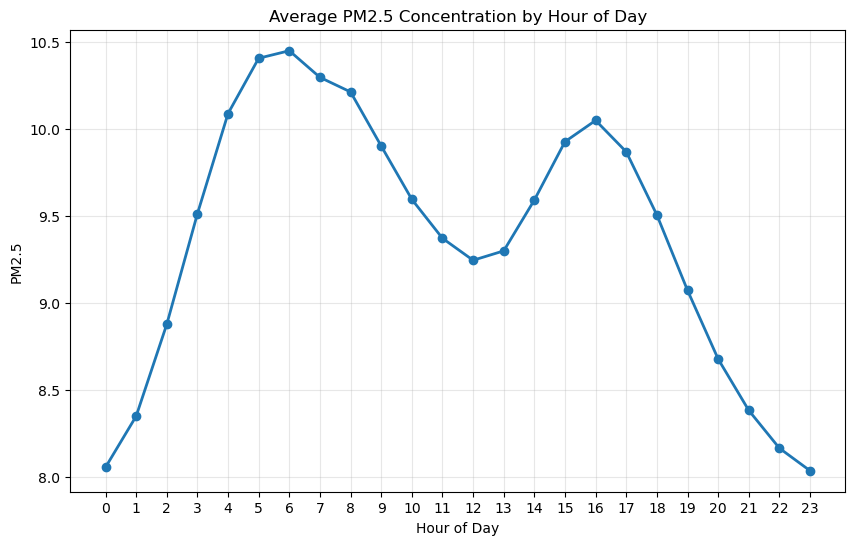

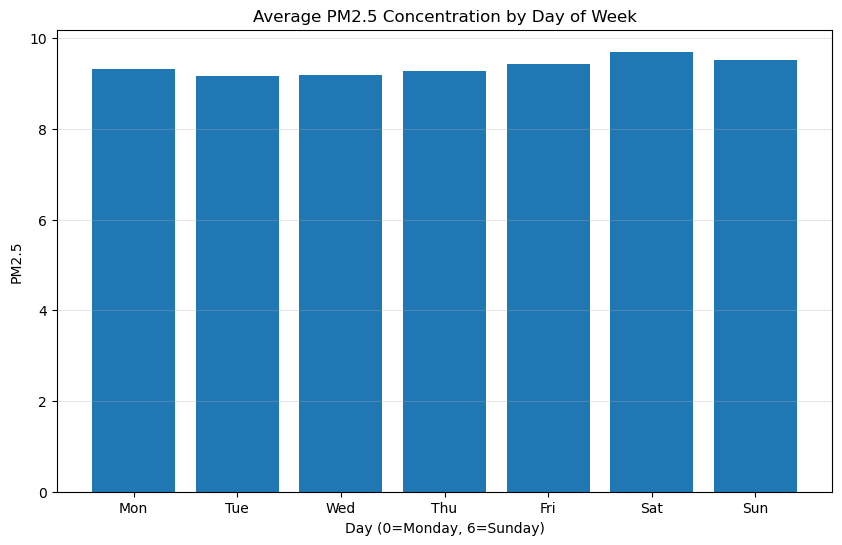

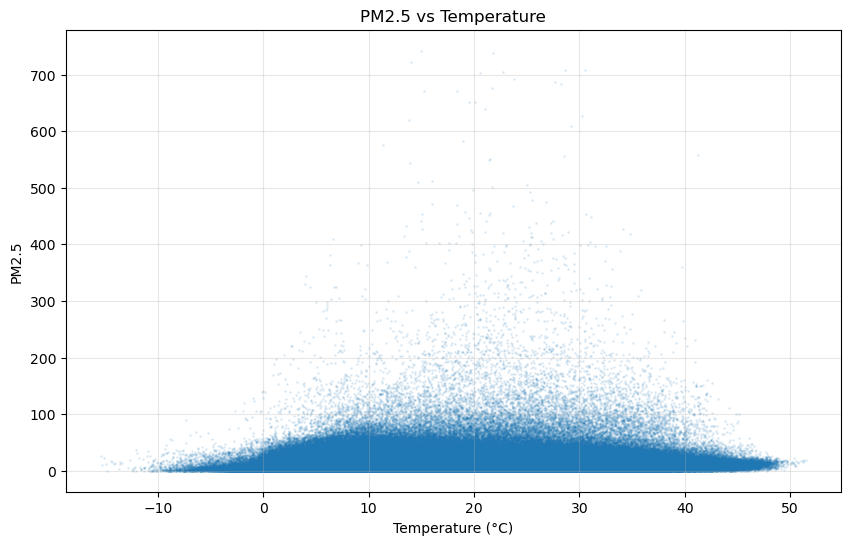

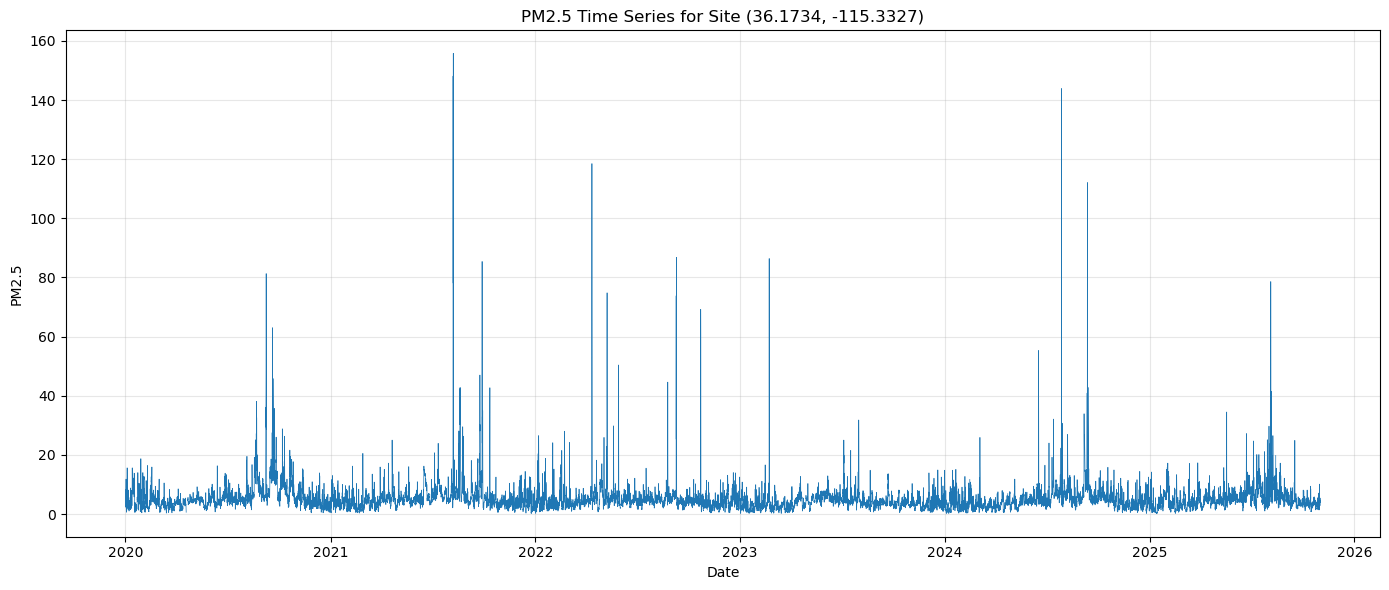

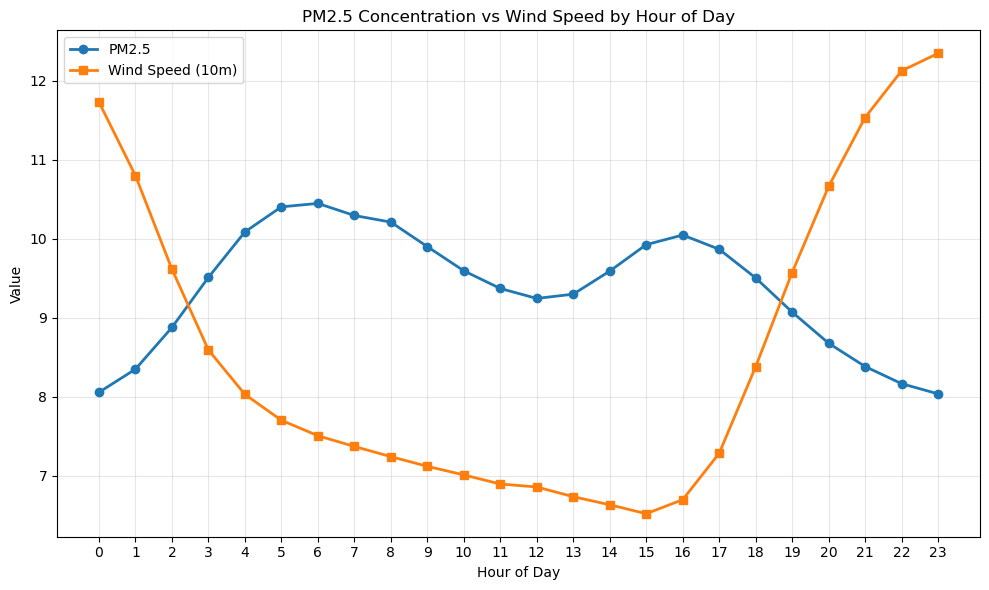

In [11]:
# PM2.5 by hour of day (rush hour patterns)
pm25_hour = df.groupby('hr')['PM2.5'].mean()

plt.figure(figsize=(10,6))
plt.plot(pm25_hour.index, pm25_hour.values, marker='o', linewidth=2)
plt.title("Average PM2.5 Concentration by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5")
plt.grid(alpha=0.3)
plt.xticks(range(24))
plt.show()

# PM2.5 by day of week (weekday vs weekend)
pm25_day = df.groupby('day')['PM2.5'].mean()

plt.figure(figsize=(10,6))
plt.bar(pm25_day.index, pm25_day.values)
plt.title("Average PM2.5 Concentration by Day of Week")
plt.xlabel("Day (0=Monday, 6=Sunday)")
plt.ylabel("PM2.5")
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(alpha=0.3, axis='y')
plt.show()


# PM2.5 vs Temperature
plt.figure(figsize=(10,6))
plt.scatter(df['temperature_2m'], df['PM2.5'], alpha=0.1, s=1)
plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5")
plt.grid(alpha=0.3)
plt.show()

# Time series of PM2.5 (sample one site)
sample_site = df.groupby(['latitude', 'longitude']).size().idxmax()
site_data = df[(df['latitude'] == sample_site[0]) & (df['longitude'] == sample_site[1])].sort_values('utc')

plt.figure(figsize=(14,6))
plt.plot(site_data['utc'], site_data['PM2.5'], linewidth=0.5)
plt.title(f"PM2.5 Time Series for Site ({sample_site[0]:.4f}, {sample_site[1]:.4f})")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# PM2.5 and Wind Speed by Hour
pm25_hour = df.groupby('hr')['PM2.5'].mean()
wind_hour = df.groupby('hr')['wind_speed_10m'].mean()

plt.figure(figsize=(10,6))
plt.plot(pm25_hour.index, pm25_hour.values, label='PM2.5', marker='o', linewidth=2)
plt.plot(wind_hour.index, wind_hour.values, label='Wind Speed (10m)', marker='s', linewidth=2)
plt.title("PM2.5 Concentration vs Wind Speed by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [12]:
df = df.dropna(subset=['PM2.5']).reset_index(drop=True)

df.tail(10)

,latitude,longitude,utc,temperature_2m,precipitation,weather_code,wind_speed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,...,PM10,PM2.5,OZONE_missing_flag,PM10_missing_flag,hr,sin_hr,cos_hr,day,sin_day,cos_day
2594245,36.72622,-119.73249,2025-10-31 15:00:00+00:00,11.980500,0.0,0.0,8.557102,345.379100,17.280000,97.074455,...,23.0,21.4,1,1,15,-0.707107,-7.071068e-01,4,0.0,-0.900969
2594246,36.72622,-119.73249,2025-10-31 16:00:00+00:00,13.480500,0.0,0.0,5.247857,5.906055,19.080000,88.576410,...,23.0,20.2,1,1,16,-0.866025,-5.000000e-01,4,0.0,-0.900969
2594247,36.72622,-119.73249,2025-10-31 17:00:00+00:00,16.330500,0.0,0.0,1.938659,68.198530,14.400000,74.953830,...,23.0,23.6,1,1,17,-0.965926,-2.588190e-01,4,0.0,-0.900969
2594248,36.72622,-119.73249,2025-10-31 18:00:00+00:00,18.830500,0.0,0.0,3.784283,267.273740,15.119999,66.161570,...,23.0,21.4,1,1,18,-1.000000,-1.836970e-16,4,0.0,-0.900969
2594249,36.72622,-119.73249,2025-10-31 19:00:00+00:00,20.980500,0.0,0.0,3.996649,277.765080,18.720000,57.910255,...,23.0,16.7,1,1,19,-0.965926,2.588190e-01,4,0.0,-0.900969
2594250,36.72622,-119.73249,2025-10-31 20:00:00+00:00,22.630499,0.0,0.0,3.758510,286.699300,18.720000,52.531440,...,23.0,13.2,1,1,20,-0.866025,5.000000e-01,4,0.0,-0.900969
2594251,36.72622,-119.73249,2025-10-31 21:00:00+00:00,23.930500,0.0,0.0,4.108576,298.810700,19.080000,48.564770,...,23.0,13.4,1,1,21,-0.707107,7.071068e-01,4,0.0,-0.900969
2594252,36.72622,-119.73249,2025-10-31 22:00:00+00:00,24.630499,0.0,0.0,4.913044,298.442800,19.440000,45.660095,...,23.0,13.3,1,1,22,-0.500000,8.660254e-01,4,0.0,-0.900969
2594253,36.72622,-119.73249,2025-10-31 23:00:00+00:00,24.680500,0.0,0.0,5.876938,297.349800,20.160000,45.225197,...,23.0,12.2,1,1,23,-0.258819,9.659258e-01,4,0.0,-0.900969
2594254,36.72622,-119.73249,2025-11-01 00:00:00+00:00,24.030499,0.0,0.0,6.720535,290.376530,19.800000,47.331566,...,23.0,9.8,1,1,0,0.000000,1.000000e+00,5,0.0,-0.222521


### Analyze Feature performance after Pre-processing

### Analyze Feature Pair Performance